# Tracking coastal sediment flow using optical flow vectors <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with both the `NCI` and `DEA Sandbox` environments
* **Products used:** 
[ga_s2ls_intertidal_cyear_3](https://explorer.dea.ga.gov.au/ga_s2ls_intertidal_cyear_3)

## Background

Intertidal coastal environments (i.e., areas of the coastline that are alternately flooded and exposed by the tide) provide critical habitat for numerous marine and coastal species.
These zones are particularly sensitive to human impacts such as coastal development, land reclamation, and resource extraction, as well as to the effects of climate change (e.g. sea level rise and changes in storm frequency and intensity).
Despite their ecological importance, intertidal zones are challenging to monitor through conventional field surveys due to their limited accessibility and highly dynamic nature, where coastal terrain can shift rapidly in response to tidal cycles, sediment transport, and extreme weather events.
This complicates efforts to understand coastal change and its impacts on ecosystems and communities.

### Digital Earth Australia use case

Satellite remote sensing offers a powerful approach to overcome these challenges, enabling consistent, large-scale, and repeatable monitoring of intertidal environments.
DEA Intertidal is a Sentinel-2 and Landsat-based product delivering annual elevation data for Australia's entire intertidal zone from 2016 onward.
By combining this unique time-series elevation dataset with modern computer vision techniques, we can track sediment movement across intertidal landscapes.
Computer vision techniques such as optical flow vectors quantify the speed and direction of sediment transport, providing new insights into coastal dynamics and the processes shaping intertidal environments.

## Description

In this example, we demonstrate how to use DEA Intertidal data to study the flow of sediment across the intertidal zone. 
Using these approaches, we generate a coastal map that highlights both the speed and direction of sediment flow. 
This analysis demonstrates how to perform the following steps:

1. Load a time series of DEA Intertidal elevation data for a coastal location.
2. Animate the data to visually explore coastal changes over time.
3. Compute rates of vertical change in elevation over time.
4. Apply optical flow analysis to quantify the direction and speed of sediment movement.
5. Plot a sediment flow map and compare it against the coastal change animation.

***


## Getting started
**To run this analysis**, run all the cells in the notebook, starting with the "Load packages" cell.

**After finishing the analysis**, return to the "Analysis parameters" cell, modify some values (e.g. choose a different location or time period to analyse) and re-run the analysis.
There are additional instructions on modifying the notebook at the end.

### Load packages
Load key Python packages and supporting functions for the analysis.

In [1]:
import sys
import cv2
import datacube
import numpy as np
import xarray as xr
import contextily as ctx
import matplotlib.pyplot as plt
from IPython.core.display import Video

sys.path.insert(1, "../Tools/")
from dea_tools.plotting import rgb, display_map, xr_animation
from dea_tools.temporal import xr_optical_flow, xr_regression

### Connect to the datacube
Activate the datacube database, which provides functionality for loading and displaying stored Earth observation data.

In [2]:
dc = datacube.Datacube(app="Tracking_sediment_flow")

### Analysis parameters

The following cell set important parameters for the analysis:

* `lat_range`: The latitude range to analyse. 
For reasonable load times, keep this to a range of ~0.1 degrees or less.
* `lon_range`: The longitude range to analyse. 
For reasonable load times, keep this to a range of ~0.1 degrees or less.
* `time_range`: The date range to analyse.

By default, this example will track coastal sediment flow across sandy tidal flats near **Bird Island north of Adelaide, South Australia.**



<div class="alert alert-info">
    
**If running the notebook for the first time**, keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.

</div>

In [3]:
lat_range = (-34.745, -34.77)
lon_range = (138.47, 138.515)
time_range = ("2016", "2023")

## View the selected location
The next cell will display the selected area on an interactive map.
Feel free to zoom in and out to get a better understanding of the area you'll be analysing.
Clicking on any point of the map will reveal the latitude and longitude coordinates of that point.

In [4]:
display_map(x=lon_range, y=lat_range)

## Load DEA Intertidal data
The first step in this analysis is to load in DEA Intertidal elevation data for the `lat_range`, `lon_range` and `time_range` we provided above. 

In [5]:
# Load available data
da = dc.load(
    product="ga_s2ls_intertidal_cyear_3",
    measurements=["elevation"],
    y=lat_range,
    x=lon_range,
    time=time_range,
).elevation

**Once the load is complete**, we can plot our data to view intertidal elevation data for our study area:

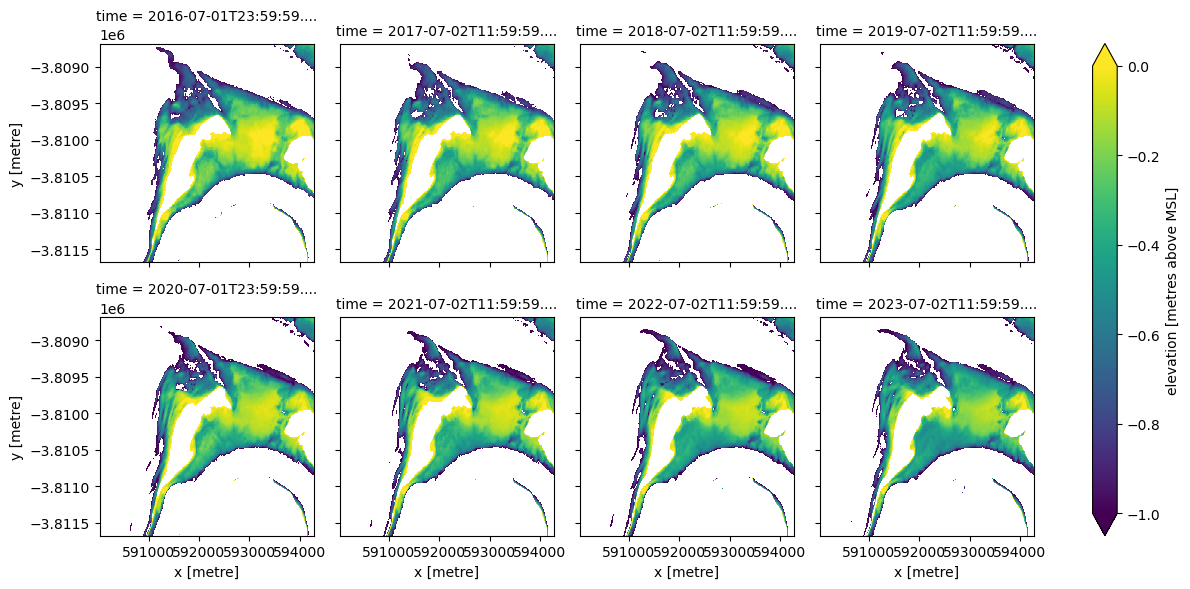

In [6]:
da.plot.imshow(col="time", cmap="viridis", col_wrap=4, vmin=-1.0, vmax=0.0);

To the naked eye, it can be difficult to visually see change between these timesteps.
It is often easier to view change using an animation.
For example, below we can clearly see areas of coastal change and moving sediment over time:

In [7]:
# Run animation
xr_animation(da.to_dataset(), bands="elevation", imshow_kwargs={"cmap": "viridis"})

# Plot animation
plt.close()
Video("animation.mp4", embed=True, html_attributes="loop autoplay")

Exporting animation to animation.mp4


  0%|          | 0/8 (0.0 seconds remaining at ? frames/s)

## Compute elevation change over time

To get a more quantitative view of how our coastal terrain has changed over time, we can use the `xr_regression` function to apply linear regression to each pixel to inspect trends of coastal change over time.

By plotting the "slope" of the regression, we can view the rate of vertical change in elevation, in metres per year.
Red pixels represent locations that are consistently losing sediment over time (e.g. erosion), while blue pixels are gaining sediment (e.g. accretion).

<div class="alert alert-info">
    
**Note:** The output of `xr_regression` contain a number of other useful regression outputs, [including p-values and standard error of the regression](https://knowledge.dea.ga.gov.au/notebooks/Tools/gen/dea_tools.temporal/#dea_tools.temporal.xr_regression). 
For example, p-values could be used to filter our results to statistically significant rates of change.

</div>


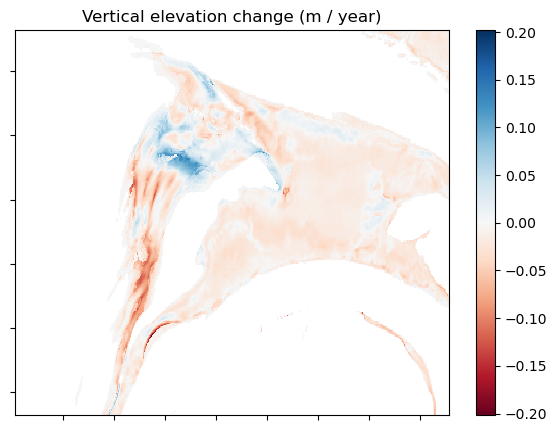

In [8]:
# Analyse vertical change over time
da_regression = xr_regression(x=da.time.dt.year, y=da)

# Plot rate of change
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
da_regression.slope.plot.imshow(ax=ax, cmap="RdBu", add_labels=False)
plt.title(f"Vertical elevation change (m / year)")
ax.set_yticklabels([])
ax.set_xticklabels([]);

## Tracking sediment movement over time

The result above only captures vertical coastal change, i.e. has a pixel gained or lost sediment. However, sediment can move laterally too, driven by coastal currents and long-shore drift.
In the following section, we use use advanced **optical flow computer vision** techniques to track the movement of sediment through the landscape over time.

### Pre-processing

Optical flow works best when an image contains visibly distinct features for the algorithm to track through time.
One approach to enhancing features in our imagery is by "sharpening" our data. 
We can achieve this using a type of spatial filter called a **high pass filter**, which will enhance sharp features, boundaries and texture in our elevation data.

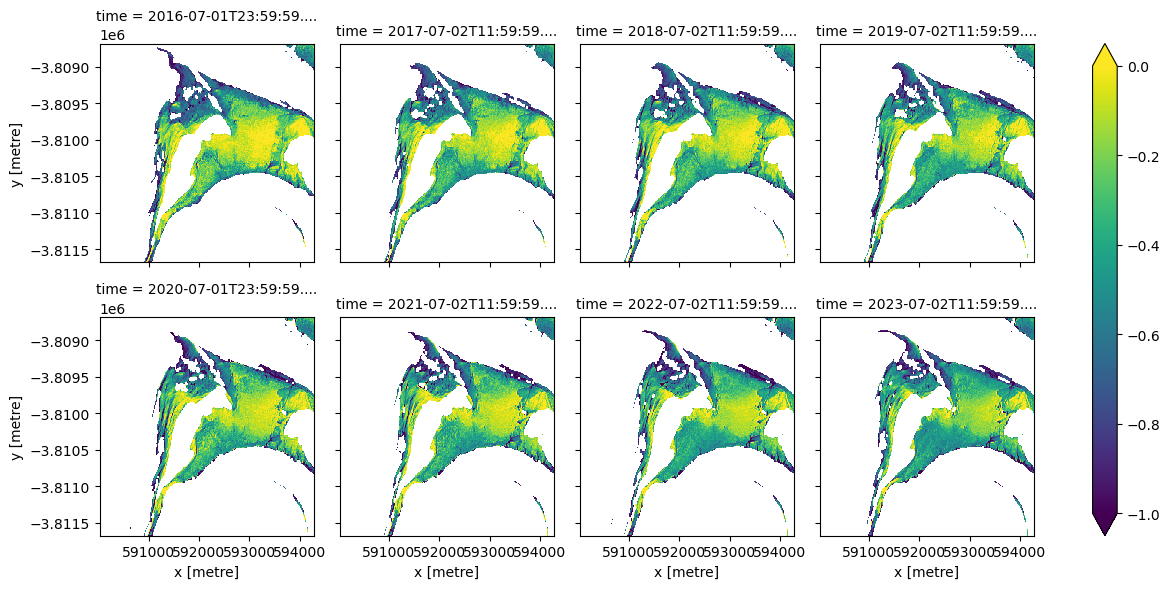

In [9]:
def sharpen(da):
    kernel = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])

    return xr.DataArray(cv2.filter2D(da.values, -1, kernel), coords=da.coords)

# Apply sharpening to each timestep
da_sharpened = da.groupby("time").apply(lambda x: sharpen(xr.DataArray(x).squeeze()))

# Plot sharpened output
da_sharpened.plot.imshow(col="time",  cmap="viridis", col_wrap=4, vmin=-1.0, vmax=0.0);

### Optical flow modelling

Now that we have a sharpened timeseries, we can use the `dea_tools.temporal.xr_optical_flow` function to run our analysis.

The function supports several different optical flow methods, defaulting to "ilk" (dense iterative Lucas–Kanade):
 
* **"ilk"**: Dense Iterative Lucas–Kanade implementation from `scikit-image`, ideal for stable and efficient motion estimation.
* **"tvl1"**: Dense Total Variation L1 from `scikit-image`, slower but more accurate motion tracking with robustness to noise.
* **"farneback"**: Dense Gunnar Farneback optical flow from `OpenCV`, suitable for smooth motion fields with polynomial interpolation.
* **"deepflow"**: Dense DeepFlow from `OpenCV`, a deep-matching-based method designed for large displacements and complex motion.
* **"lucas_kanade"**: Sparse pyramidal Lucas–Kanade from `OpenCV`, returns motion vectors for selected point locations rather than the entire input array extent.

By default, this function will operate in `baseline="dynamic"` mode, which will automatically iterate through our dataset and compare change between each pair of consecutive timesteps. 
Other baseline options are available, including `baseline="first"` which will compare each timestep againt the first array in the timeseries.
You can also pass a custom `xr.DataArray` to `baseline=...`.




<div class="alert alert-info">
    
**Note:** The optical flow methods supported by the `xr_optical_flow` function do not support NaN values, so in this example we naively set these to 0 before we run the analysis.
This step could be improved by a more robust NaN filling method.

</div>


In [10]:
ds_flow = xr_optical_flow(da_sharpened.fillna(0), method="ilk", baseline="dynamic")
ds_flow


Computing optical flow (ilk) in parallel: 100%|██████████| 7/7 [00:27<00:00,  3.88s/it]


<xarray.Dataset> Size: 11MB
Dimensions:      (time: 7, y: 300, x: 425)
Coordinates:
  * y            (y) float64 2kB -3.809e+06 -3.809e+06 ... -3.812e+06 -3.812e+06
  * x            (x) float64 3kB 5.9e+05 5.9e+05 ... 5.943e+05 5.943e+05
    spatial_ref  int32 4B 3577
  * time         (time) datetime64[ns] 56B 2017-07-02T11:59:59.999999 ... 202...
Data variables:
    v            (time, y, x) float32 4MB 0.0 0.0 0.0 ... 0.9301 0.8817 0.8812
    u            (time, y, x) float32 4MB 0.0 0.0 0.0 ... 0.1172 0.1385 0.1362
    magnitude    (time, y, x) float32 4MB 0.0 0.0 0.0 ... 0.9374 0.8925 0.8917

The output above includes optical flow results for each pair of comparison time steps. 
To produce a single output figure that summarises sediment flow over time, we now mask our data to pixels that contain valid results in all timesteps, then take the median of our annual change results:

In [11]:
# Compute median flow over time
valid_mask = da.notnull().all(dim="time")
ds_flow_summary = ds_flow.where(valid_mask).median(dim="time")

### Plotting

We can now plot our optical flow vectors.
The arrows on the map represent the flow of sediment through the landscape, with longer arrows indicating more rapid movement (i.e. higher rates of change per year).

At this location, we can see the effect of long-shore sediment drift from the south, bringing sediment in a north-easterly direction around Bird Island.

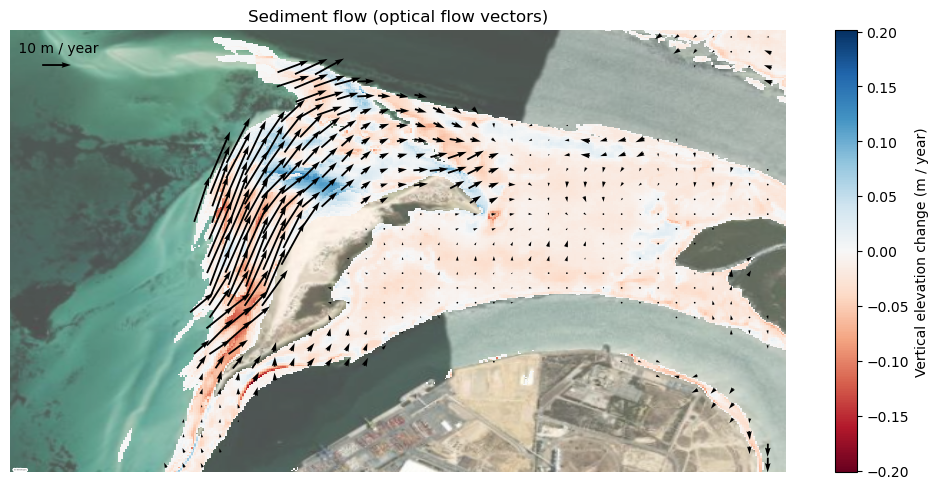

In [12]:
# Create figure
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Sub-sample array for clearer quiver plot
ds_flow_coarse = ds_flow_summary.coarsen({"x": 10, "y": 10}, boundary="trim").median()

# Flip vertical axis to avoid xarray issue where negative Y
# coordinates cause vectors to be inverted
ds_flow_coarse["v"] = -ds_flow_coarse.v

# Plot background rate of vertical change image
da_regression.slope.plot(
    ax=ax,
    cmap="RdBu",
    cbar_kwargs={"label": "Vertical elevation change (m / year)"},
)

# Add a basemap for context
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    crs="EPSG:3577",
    attribution="Esri WorldImagery",
    attribution_size=1,
    alpha=0.7,
)

# Add quiver plot directly from xarray
quiver = ds_flow_coarse.plot.quiver(
    x="x",
    y="y",
    u="u",
    v="v",
    ax=ax,
    color="black",
    pivot="mid",
    add_guide=False,
)

# Add key and plot title
ax.quiverkey(quiver, 0.06, 0.92, 1, " 10 m / year")
ax.set_title("Sediment flow (optical flow vectors)")
ax.set_axis_off()
fig.tight_layout();

To verify the results we are seeing above make sense, we can compare them to our previous animation. 
We can see that the optical flow vectors correctly mark the areas we can see moving in the animation.

In [13]:
# Plot animation
plt.close()
Video("animation.mp4", embed=True, html_attributes="loop autoplay")

## Next steps
When you are done, return to the **Optical flow modelling** step, and test out different optical flow methods (e.g. `xr_optical_flow(..., method="tvl1")`) or baseline options (e.g. `xr_optical_flow(..., baseline="first")`).

You can also try running the analysis on a new location by returning to **Analysis parameters** and changing the latitude and longitude study area location. 
If you're going to change the location, you'll need to make sure DEA Intertidal data is available for the new location, which you can check at the [DEA Explorer](https://explorer.dea.ga.gov.au/ga_s2ls_intertidal_cyear_3).

***
## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** October 2025

**Compatible datacube version:** 

In [14]:
print(datacube.__version__)

1.9.9


## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->